# Day 02：记忆的种子 —— RNN 的诞生与隐藏状态> ⏳ 第九周 · 记忆的诞生 · 第 2 天昨天我们看到了前馈网络的"金鱼困境"——没有记忆，就无法理解序列。今天，我们要给神经网络装上"记忆"。方法出奇地简单：**让网络的输出不仅取决于当前输入，还取决于上一时刻的"记忆"。**这就是循环神经网络（Recurrent Neural Network, RNN）的核心思想。**今天的任务**：1. 理解 RNN 的核心公式：$h_t = \tanh(W_{xh} x_t + W_{hh} h_{t-1} + b)$2. 理解"隐藏状态"——RNN 的记忆载体3. 用代码从零实现一个 RNN 单元---

## 1. 历史剧场：1986 年的"记忆革命"1986 年，Rumelhart、Hinton 和 Williams 发表了那篇改变历史的论文，不仅让反向传播流行开来，还提出了一个关键想法：> **如果网络的输出不仅取决于当前输入，还取决于之前的"内部状态"，那网络就有了记忆。**这个"内部状态"就是**隐藏状态（Hidden State）**，通常记为 $h$。RNN 的诞生，让神经网络第一次拥有了"记住过去"的能力。---

## 2. 生活隐喻：边看边记的读书人- **前馈网络**：像拍照——每一页都是独立的照片，照片之间没有联系- **RNN**：像读书——你逐字逐句地读，每读到一个新词，你把它和之前记住的内容结合起来，形成新的理解具体来说：

<p align="center">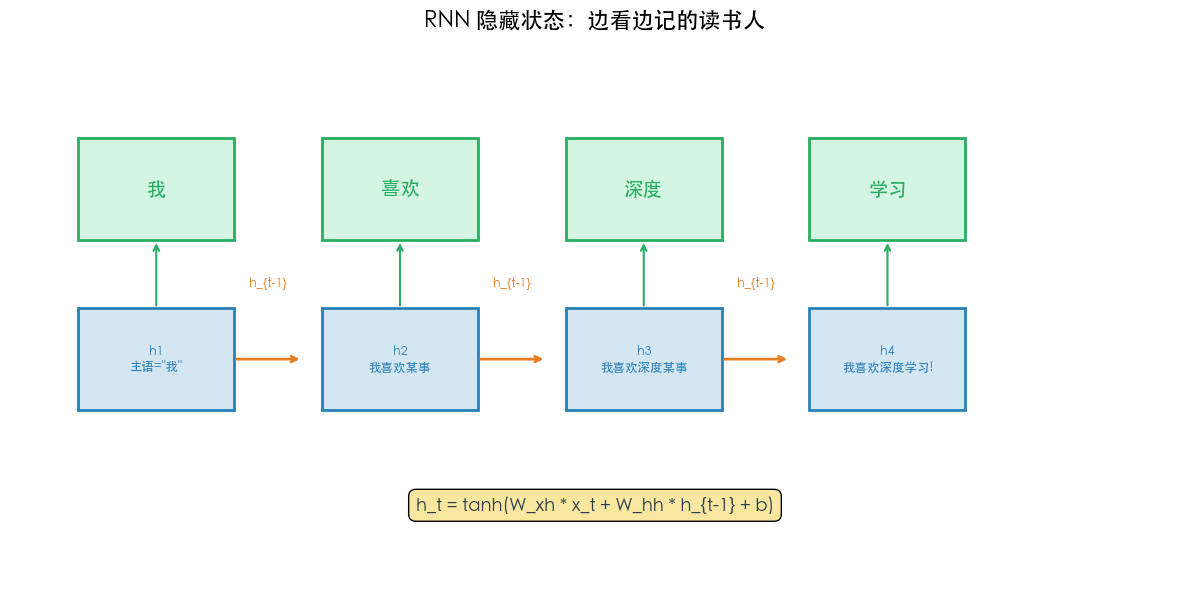</p>*RNN 隐藏状态工作原理图*

你正在读："我 喜欢 深度 学习"读到"我"：h1 = 理解("我")           → 记住：主语是"我"读到"喜欢"：h2 = 理解("喜欢", h1)    → 记住：我喜欢某事读到"深度"：h3 = 理解("深度", h2)    → 记住：我喜欢深度某事读到"学习"：h4 = 理解("学习", h3)    → 记住：我喜欢深度学习！

每一步，RNN 都在做两件事：1. **处理当前输入**（读新词）2. **结合之前的记忆**（和 h_{t-1} 结合）---

## 3. 数学直觉：RNN 的核心公式RNN 的核心公式非常简洁：$$h_t = \tanh(W_{xh} \cdot x_t + W_{hh} \cdot h_{t-1} + b)$$拆开来看：| 符号 | 含义 | 直觉 ||---|---|---|| $x_t$ | 当前时刻的输入 | 正在读的新词 || $h_{t-1}$ | 上一时刻的隐藏状态 | 之前记住的内容 || $W_{xh}$ | 输入到隐藏的权重 | "新信息有多重要" || $W_{hh}$ | 隐藏到隐藏的权重 | "旧记忆有多重要" || $\tanh$ | 激活函数 | 把结果压缩到 [-1, 1] || $h_t$ | 当前时刻的隐藏状态 | "结合新旧信息后的新记忆" |**关键洞察**：$h_t$ 是"新输入"和"旧记忆"的加权混合。$W_{hh}$ 控制了"记住多少过去"，$W_{xh}$ 控制了"关注多少现在"。---

## 4. 代码实验室：从零手写 RNN 单元

In [ ]:
import torchimport torch.nn as nnimport matplotlib.pyplot as pltimport numpy as npplt.rcParams['font.sans-serif'] = ['Arial Unicode MS', 'SimHei']plt.rcParams['axes.unicode_minus'] = False

### 4.1 手写 RNN 单元

In [ ]:
class SimpleRNNCell:    """从零手写的 RNN 单元"""    def __init__(self, input_size, hidden_size):        self.input_size = input_size        self.hidden_size = hidden_size        scale_xh = np.sqrt(2.0 / (input_size + hidden_size))        scale_hh = np.sqrt(2.0 / (hidden_size + hidden_size))        self.W_xh = np.random.randn(hidden_size, input_size) * scale_xh        self.W_hh = np.random.randn(hidden_size, hidden_size) * scale_hh        self.b = np.zeros(hidden_size)    def forward(self, x_t, h_prev):        h_t = np.tanh(self.W_xh @ x_t + self.W_hh @ h_prev + self.b)        return h_t    def init_hidden(self):        return np.zeros(self.hidden_size)rnn_cell = SimpleRNNCell(input_size=4, hidden_size=8)print("RNN 单元创建成功!")print(f"  W_xh 形状: {rnn_cell.W_xh.shape}")print(f"  W_hh 形状: {rnn_cell.W_hh.shape}")print(f"  b 形状: {rnn_cell.b.shape}")

### 4.2 逐步处理序列

In [ ]:
np.random.seed(42)sequence_length = 6input_size = 4hidden_size = 8rnn = SimpleRNNCell(input_size, hidden_size)h = rnn.init_hidden()print("逐步处理序列：")print("-" * 50)hidden_states = [h.copy()]for t in range(sequence_length):    x_t = np.random.randn(input_size)    h = rnn.forward(x_t, h)    hidden_states.append(h.copy())    print(f"  时刻 {t}: 输入范数={np.linalg.norm(x_t):.3f}, "          f"隐藏状态范数={np.linalg.norm(h):.3f}, "          f"隐藏状态均值={h.mean():.4f}")

### 4.3 可视化隐藏状态的变化

In [ ]:
hidden_array = np.array(hidden_states[1:])fig, axes = plt.subplots(1, 2, figsize=(14, 5))ax = axes[0]im = ax.imshow(hidden_array.T, aspect='auto', cmap='RdBu_r', vmin=-1, vmax=1)ax.set_xlabel('时间步', fontsize=12)ax.set_ylabel('隐藏维度', fontsize=12)ax.set_title('隐藏状态热力图：记忆如何随时间变化', fontsize=14)plt.colorbar(im, ax=ax, label='激活值')ax = axes[1]for i in range(min(4, hidden_size)):    ax.plot(hidden_array[:, i], label=f'维度{i}', alpha=0.8)ax.set_xlabel('时间步', fontsize=12)ax.set_ylabel('激活值', fontsize=12)ax.set_title('各隐藏维度的变化轨迹', fontsize=14)ax.legend(fontsize=10)ax.grid(True, alpha=0.3)plt.tight_layout()plt.show()

### 解读- **热力图**：每一列是一个时间步，每一行是一个隐藏维度。颜色变化说明记忆在更新- **轨迹图**：不同维度以不同方式响应输入，就像大脑中不同的神经元关注不同的信息---

## 5. 几何直觉：RNN 的"信息回路"前馈网络的信息流是**单向**的：

输入 → 隐藏层 → 输出

RNN 的信息流是**循环**的：

输入 + 旧记忆 → 新记忆 → 输出                ↓              (新记忆变成下一步的旧记忆)

这个循环就是 RNN 拥有"记忆"的秘密。每一步，新信息 $x_t$ 和旧记忆 $h_{t-1}$ 混合，产生新记忆 $h_t$。新记忆又传给下一步，如此循环。**RNN 的本质**：一个不断更新的"记忆黑板"。每读一个新词，就在黑板上更新笔记。---

## 今日结语今天我们认识了 RNN 的核心——隐藏状态 $h_t$。它就像一个不断更新的记忆：$$h_t = \tanh(W_{xh} \cdot x_t + W_{hh} \cdot h_{t-1} + b)$$新输入和旧记忆混合，产生新记忆。这个简单的循环，赋予了神经网络"记住过去"的能力。但 RNN 的记忆真的可靠吗？明天我们将看到它最大的弱点——**梯度消失**在序列上的回归。---### 翻译词典| 生活中的直觉 | 深度学习术语 ||---|---|| 读书时边看边记 | RNN——循环处理，保留隐藏状态 || 之前的理解影响当前理解 | 隐藏状态 h_{t-1} 影响h_t || 记忆黑板——不断更新 | 隐藏状态——每步更新 || 新信息 + 旧记忆 = 新理解 | x_t + h_{t-1} → h_t || 记住多少过去 vs 关注多少现在 | W_{hh} vs W_{xh} 的权重比例 |